# HMEQ — Exploratory Data Analysis

Home Equity (HMEQ) loan performance dataset. Target `BAD` = 1 if the
applicant defaulted or was seriously delinquent on the loan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/hmeq.csv")
df.shape

(5960, 13)

## Shape, dtypes, head

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   str    
 5   JOB      5681 non-null   str    
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), str(2)
memory usage: 605.4 KB


In [3]:
df.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


## Target distribution

BAD
0    4771
1    1189
Name: count, dtype: int64
Default rate: 19.95%


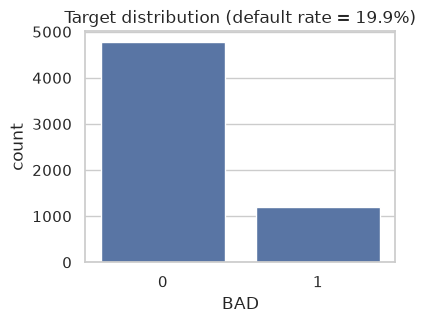

In [4]:
bad_counts = df["BAD"].value_counts().sort_index()
bad_rate = df["BAD"].mean()
print(bad_counts)
print(f"Default rate: {bad_rate:.2%}")

fig, ax = plt.subplots(figsize=(4, 3))
sns.countplot(x="BAD", data=df, ax=ax)
ax.set_title(f"Target distribution (default rate = {bad_rate:.1%})")
plt.show()

## Missingness

DEBTINC    0.212584
DEROG      0.118792
DELINQ     0.097315
MORTDUE    0.086913
YOJ        0.086409
NINQ       0.085570
CLAGE      0.051678
JOB        0.046812
REASON     0.042282
CLNO       0.037248
VALUE      0.018792
dtype: float64


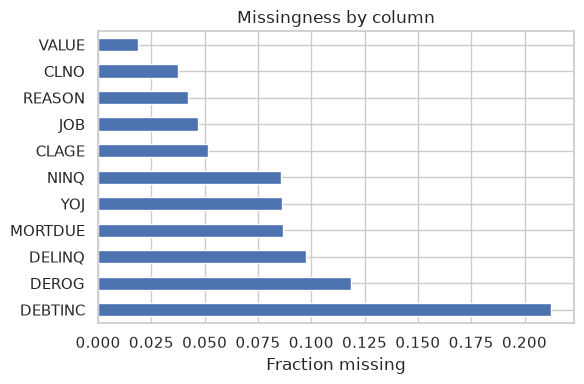

In [5]:
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print(missing)

fig, ax = plt.subplots(figsize=(6, 4))
missing.plot(kind="barh", ax=ax)
ax.set_xlabel("Fraction missing")
ax.set_title("Missingness by column")
plt.tight_layout()
plt.show()

## Univariate distributions

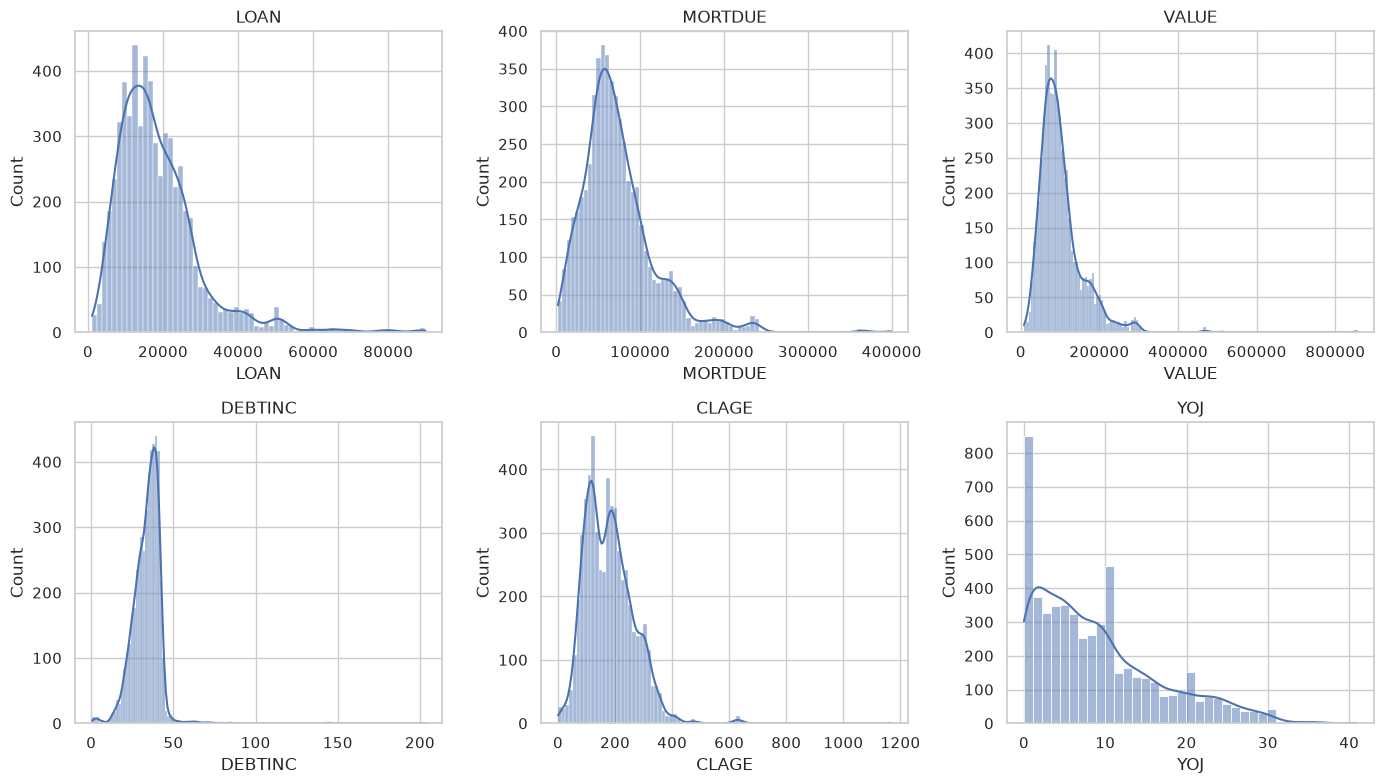

In [6]:
numeric_cols = ["LOAN", "MORTDUE", "VALUE", "DEBTINC", "CLAGE", "YOJ"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for col, ax in zip(numeric_cols, axes.ravel()):
    sns.histplot(df[col].dropna(), ax=ax, kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

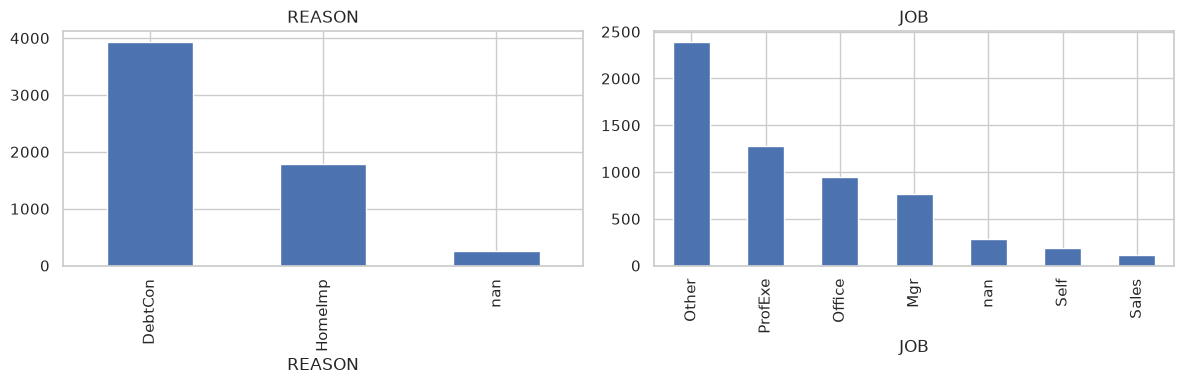

In [7]:
cat_cols = ["REASON", "JOB"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for col, ax in zip(cat_cols, axes):
    df[col].value_counts(dropna=False).plot(kind="bar", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Bivariate: default rate by category, numeric distributions by BAD

In [8]:
for col in cat_cols:
    rate = df.groupby(col)["BAD"].mean().sort_values(ascending=False)
    print(f"\nDefault rate by {col}:")
    print(rate)


Default rate by REASON:
REASON
HomeImp    0.222472
DebtCon    0.189664
Name: BAD, dtype: float64

Default rate by JOB:
JOB
Sales      0.348624
Self       0.300518
Mgr        0.233377
Other      0.231993
ProfExe    0.166144
Office     0.131857
Name: BAD, dtype: float64


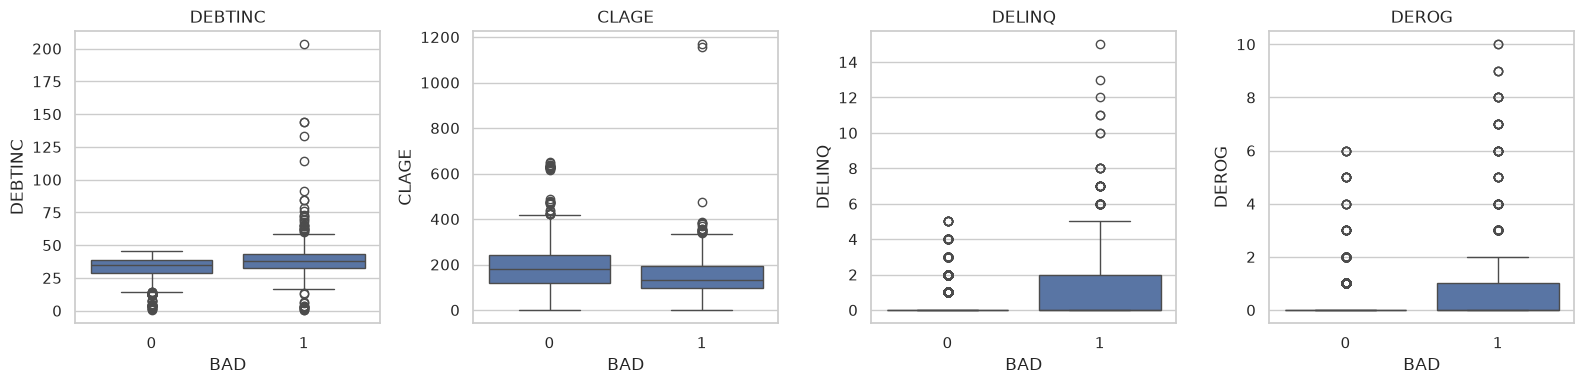

In [9]:
box_cols = ["DEBTINC", "CLAGE", "DELINQ", "DEROG"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for col, ax in zip(box_cols, axes):
    sns.boxplot(x="BAD", y=col, data=df, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Correlation heatmap

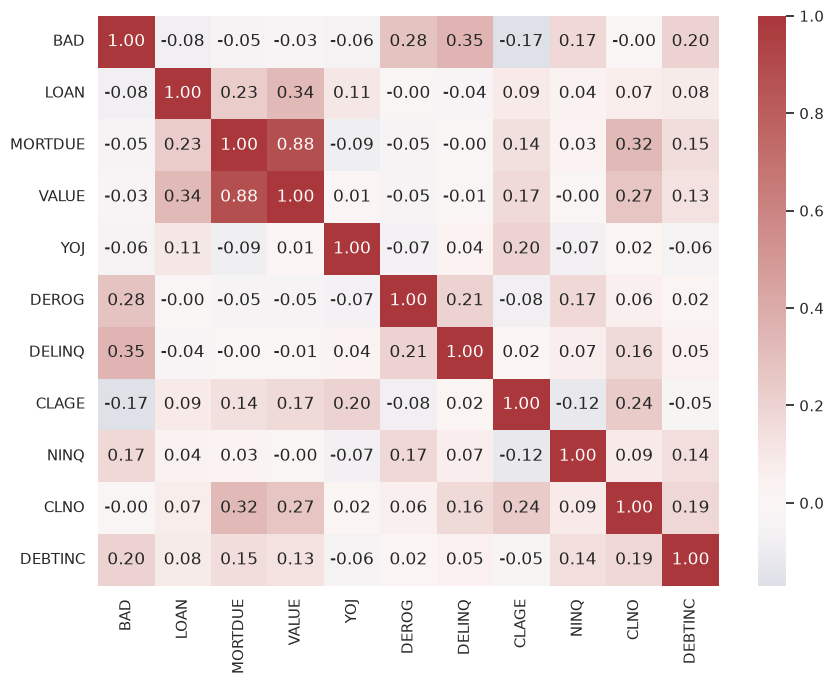

In [10]:
num_df = df.select_dtypes(include=[np.number])
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
plt.tight_layout()
plt.show()

## Data quality scan

In [11]:
value_lt_mortdue = (df["VALUE"] < df["MORTDUE"]).sum()
print(f"Rows where VALUE < MORTDUE: {value_lt_mortdue}")

negatives = (num_df < 0).sum()
negatives = negatives[negatives > 0]
print("Columns with negative values:")
print(negatives if len(negatives) else "none")

Rows where VALUE < MORTDUE: 51
Columns with negative values:
none


## Missingness vs. target

Does missing `DEBTINC` (or other fields) correlate with default risk?
This directly motivates adding `{col}_MISSING` indicator flags in
`data_prep.py` rather than silently imputing.

In [12]:
missing_flag_cols = missing.index.tolist()
for col in missing_flag_cols:
    rate_missing = df.loc[df[col].isna(), "BAD"].mean()
    rate_present = df.loc[df[col].notna(), "BAD"].mean()
    print(f"{col:10s}  default rate | missing={rate_missing:.2%}  present={rate_present:.2%}")

DEBTINC     default rate | missing=62.04%  present=8.59%
DEROG       default rate | missing=12.29%  present=20.98%
DELINQ      default rate | missing=12.41%  present=20.76%
MORTDUE     default rate | missing=20.46%  present=19.90%
YOJ         default rate | missing=12.62%  present=20.64%
NINQ        default rate | missing=14.71%  present=20.44%
CLAGE       default rate | missing=25.32%  present=19.66%
JOB         default rate | missing=8.24%  present=20.52%
REASON      default rate | missing=19.05%  present=19.99%
CLNO        default rate | missing=23.87%  present=19.80%
VALUE       default rate | missing=93.75%  present=18.54%


## Key findings

1. **Class imbalance**: ~20% default rate (`BAD=1`) — mild imbalance,
   manageable with `class_weight='balanced'` / `scale_pos_weight` rather
   than synthetic oversampling.
2. **Missingness is informative, not random**: rows with missing `DEBTINC`,
   `DEROG`, or `DELINQ` show a meaningfully different default rate than
   rows with the field present — this justifies adding explicit
   `_MISSING` indicator columns before imputation rather than imputing
   silently.
3. **DEROG/DELINQ relationship with default**: accounts with any
   derogatory reports or delinquent trade lines default at a
   substantially higher rate — these are the strongest bureau-attribute
   predictors, consistent with real-world credit risk intuition.
4. **Skewed, outlier-heavy continuous fields**: `DEBTINC`, `CLAGE`,
   `VALUE`, and `MORTDUE` all show heavy right-skew with extreme
   outliers — raw linear-model use would be dominated by these outliers,
   motivating WOE/IV binning for the scorecard rather than raw features.
5. **REASON/JOB as segmentation dimensions**: default rate varies
   meaningfully by loan purpose and occupation, making both useful
   segment cuts for the later portfolio-level Expected Loss aggregation.